In [1]:
# --- AJOUT DES DÉCODEURS POUR ÉVITER LES ÉCRANS NOIRS ---
!pip install -q grad-cam pydicom nibabel pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

import os, glob, numpy as np, pandas as pd, pydicom, cv2, torch, torch.nn as nn, nibabel as nib
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split

BASE_PATH = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"
TRAIN_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
SEG_DIR = os.path.join(BASE_PATH, "segmentations")

class RSNAKaggleDataset(Dataset):
    def __init__(self, df, image_dir, seg_dir=None):
        self.df = df
        self.image_dir = image_dir
        self.seg_dir = seg_dir

    def __len__(self): return len(self.df)

    def get_anatomical_centers(self, uid, num_slices):
        seg_path = os.path.join(self.seg_dir, f"{uid}.nii.gz")
        if os.path.exists(seg_path):
            try:
                data = nib.load(seg_path).get_fdata()
                centers = []
                for v_idx in range(1, 8):
                    z = np.where(data == v_idx)[2]
                    centers.append(int(np.median(z)) if len(z) > 0 else -1)
                return centers
            except: pass
        
        start = int(num_slices * 0.2)
        end = int(num_slices * 0.8)
        return np.linspace(start, end, 7).astype(int)

    def preprocess_slice(self, path):
        try:
            dicom = pydicom.dcmread(path)
            # Maintenant pydicom pourra décoder les images compressées
            img = dicom.pixel_array.astype(np.float32) 
            
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-6)
            return cv2.resize(img, (224, 224))
        except: 
            return None

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(float)
        path = os.path.join(self.image_dir, uid)
        slices = sorted(glob.glob(os.path.join(path, "*.dcm")), key=lambda x: int(os.path.basename(x).replace('.dcm', '')))
        
        vertebrae_stacks = []
        centers = self.get_anatomical_centers(uid, len(slices))
        for mid in centers:
            temp_stack = []
            if mid == -1: 
                vertebrae_stacks.append(np.zeros((7, 224, 224)))
                continue
            for i in range(-3, 4): 
                idx_s = max(0, min(len(slices)-1, mid + i))
                s = self.preprocess_slice(slices[idx_s])
                temp_stack.append(s if s is not None else np.zeros((224, 224)))
            vertebrae_stacks.append(np.stack(temp_stack, axis=0))
        return torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

class MultiVertebraModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights='DEFAULT')
        base.conv1 = nn.Conv2d(7, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w) 
        features = self.encoder(x).view(bs * nv, -1)
        return self.fc(features).view(bs, nv)

print("Cella 1 OK : Décodeurs DICOM installés !")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.5 MB/s eta 0:00:00
Cella 1 OK : Décodeurs DICOM installés !


Visualizzando: 1.2.826.0.1.3680043.26498.nii | Forma: (512, 512, 363)


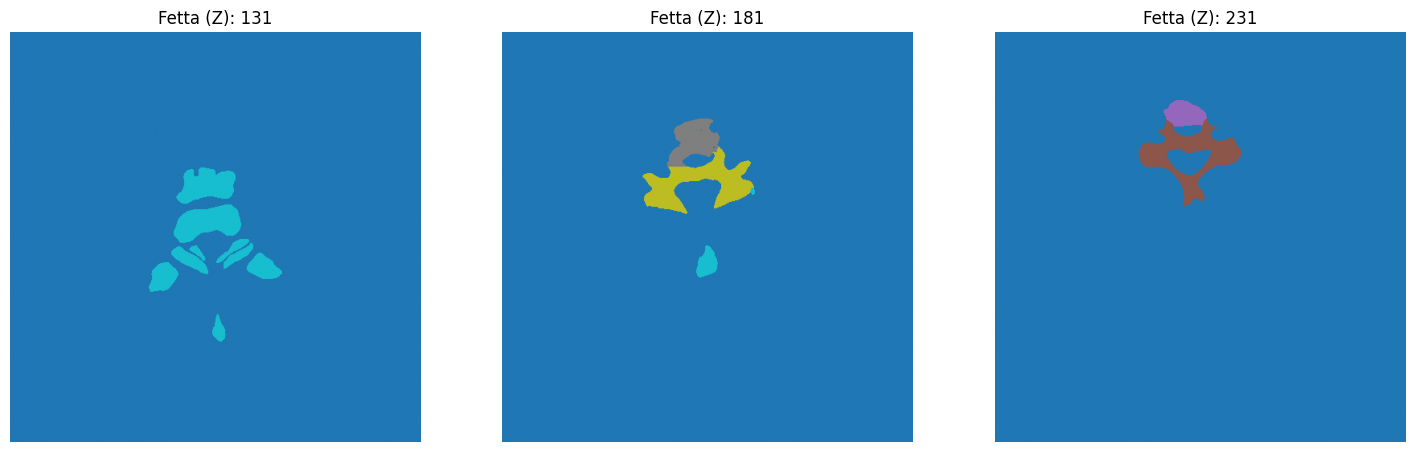

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def esplora_segmentazioni(seg_dir, num_esempi=1):
    # je cherche .nii ET .nii.gz pour être sûr
    seg_files = [f for f in os.listdir(seg_dir) if f.endswith(('.nii', '.nii.gz'))]
    
    if not seg_files:
        print(f"Errore: Nessun file trovato in {seg_dir}")
        return

    for _ in range(num_esempi):
        file_scelto = random.choice(seg_files)
        path_completo = os.path.join(seg_dir, file_scelto)
        
        img = nib.load(path_completo)
        data = img.get_fdata()
        
        # Correction d'orientation fréquente pour NIfTI sur Kaggle
        data = np.transpose(data, (1, 0, 2))
        data = np.flip(data, axis=0)

        print(f"Visualizzando: {file_scelto} | Forma: {data.shape}")
        
        z_mid = data.shape[2] // 2
        fette = [max(0, z_mid - 50), z_mid, min(data.shape[2]-1, z_mid + 50)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for i, f in enumerate(fette):
            slice_data = data[:, :, f]
            #  j'utilise 'tab10' pour bien voir les 7 vertèbres (couleurs distinctes)
            im = axes[i].imshow(slice_data, cmap='tab10', vmin=0, vmax=7)
            axes[i].set_title(f"Fetta (Z): {f}")
            axes[i].axis('off')
        
        plt.show()

#  SEG_DIR  doit etre bien défini
SEG_DIR = os.path.join(BASE_PATH, "segmentations")
esplora_segmentazioni(SEG_DIR, num_esempi=1)

In [3]:
def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    df = pd.read_csv(TRAIN_CSV)
    
    # Liste des patients avec segmentation parfaite
    seg_ids = [f.replace('.nii.gz', '').replace('.nii', '') for f in os.listdir(SEG_DIR)]
    
    # Dataset équilibré : Patients segmentés + 200 aléatoires
    df_final = pd.concat([
        df[df['StudyInstanceUID'].isin(seg_ids)], 
        df[~df['StudyInstanceUID'].isin(seg_ids)].sample(n=200, random_state=42)
    ]).sample(frac=1).reset_index(drop=True)
    
    train_df, val_df = train_test_split(df_final, test_size=0.15, random_state=42)

    train_loader = DataLoader(RSNAKaggleDataset(train_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=4, shuffle=True)
    val_loader = DataLoader(RSNAKaggleDataset(val_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=4)

    model = MultiVertebraModel().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    
    # AUGMENTATION DU POIDS : je force le modèle à chercher les vraies fractures
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(DEVICE))

    print(f"Training avviato su {len(df_final)} pazienti totali.")
    print("-" * 60)

    for epoch in range(5):
        # --- ENTRAÎNEMENT ---
        model.train()
        epoch_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
            # Affichage 
            if i % 20 == 0: 
                print(f"Epoca [{epoch+1}/5] | Batch {i}/{len(train_loader)} | Loss Train: {loss.item():.4f}")
        
        # --- VALIDATION ---
        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for v_images, v_labels in val_loader:
                v_images, v_labels = v_images.to(DEVICE), v_labels.to(DEVICE)
                v_outputs = model(v_images)
                
                v_loss = criterion(v_outputs, v_labels)
                val_loss += v_loss.item()
                
                preds = (torch.sigmoid(v_outputs) > 0.5).float()
                correct += (preds == v_labels).sum().item()
                total += v_labels.numel()
        
        # Calculs des moyennes pour le résumé de fin d'époque
        avg_train_loss = epoch_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / total
        
        
        print(f"\n--- FINE EPOCA {epoch+1} ---")
        print(f"Loss Media Train: {avg_train_loss:.4f}")
        print(f"Loss Media Val: {avg_val_loss:.4f}")
        print(f"Accuracy Validation: {accuracy:.4f}\n")

    torch.save(model.state_dict(), "/kaggle/working/cervical_model_final.pth")
    return model, val_df

model, val_df = run_training()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


Training avviato su 287 pazienti totali.
------------------------------------------------------------
Epoca [1/5] | Batch 0/61 | Loss Train: 1.2097
Epoca [1/5] | Batch 20/61 | Loss Train: 1.1815
Epoca [1/5] | Batch 40/61 | Loss Train: 1.1814
Epoca [1/5] | Batch 60/61 | Loss Train: 1.0008

--- FINE EPOCA 1 ---
Loss Media Train: 1.1224
Loss Media Val: 1.1603
Accuracy Validation: 0.3799

Epoca [2/5] | Batch 0/61 | Loss Train: 0.9945
Epoca [2/5] | Batch 20/61 | Loss Train: 0.9692
Epoca [2/5] | Batch 40/61 | Loss Train: 0.9245
Epoca [2/5] | Batch 60/61 | Loss Train: 0.8919

--- FINE EPOCA 2 ---
Loss Media Train: 0.9700
Loss Media Val: 1.1498
Accuracy Validation: 0.5390

Epoca [3/5] | Batch 0/61 | Loss Train: 0.7658
Epoca [3/5] | Batch 20/61 | Loss Train: 0.8026
Epoca [3/5] | Batch 40/61 | Loss Train: 0.8235
Epoca [3/5] | Batch 60/61 | Loss Train: 0.8359

--- FINE EPOCA 3 ---
Loss Media Train: 0.8635
Loss Media Val: 1.1842
Accuracy Validation: 0.6364

Epoca [4/5] | Batch 0/61 | Loss Train: 0

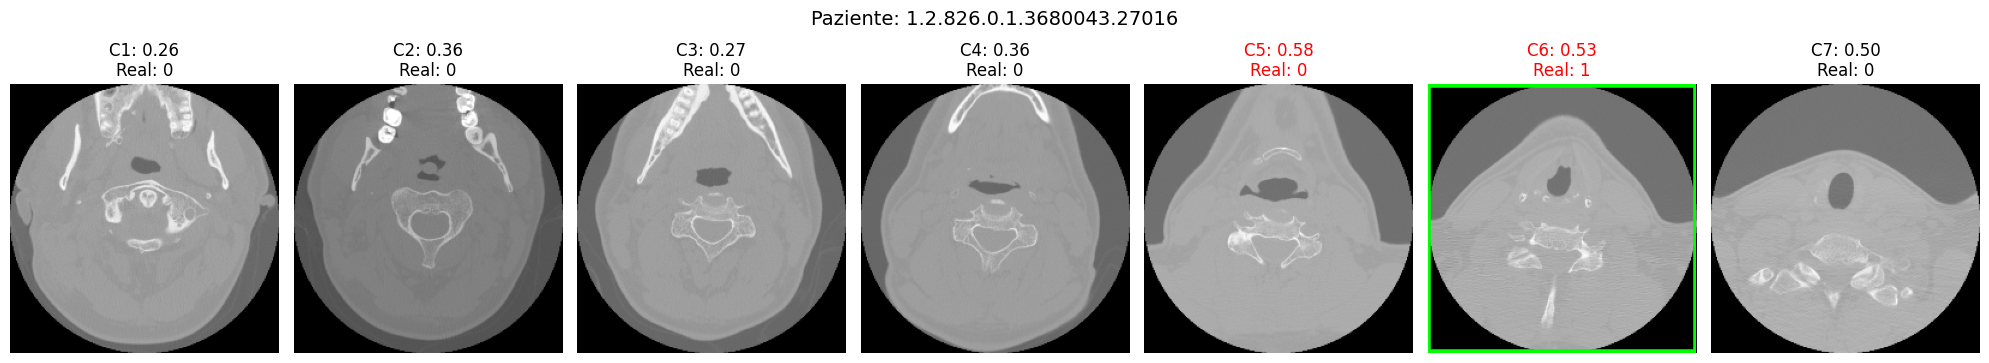

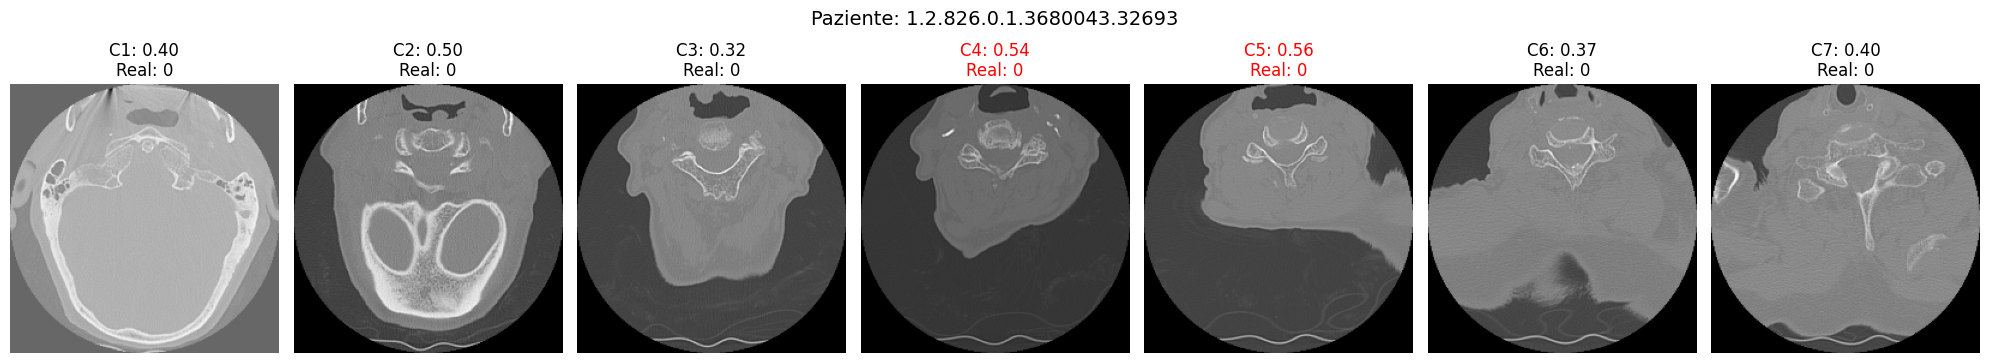

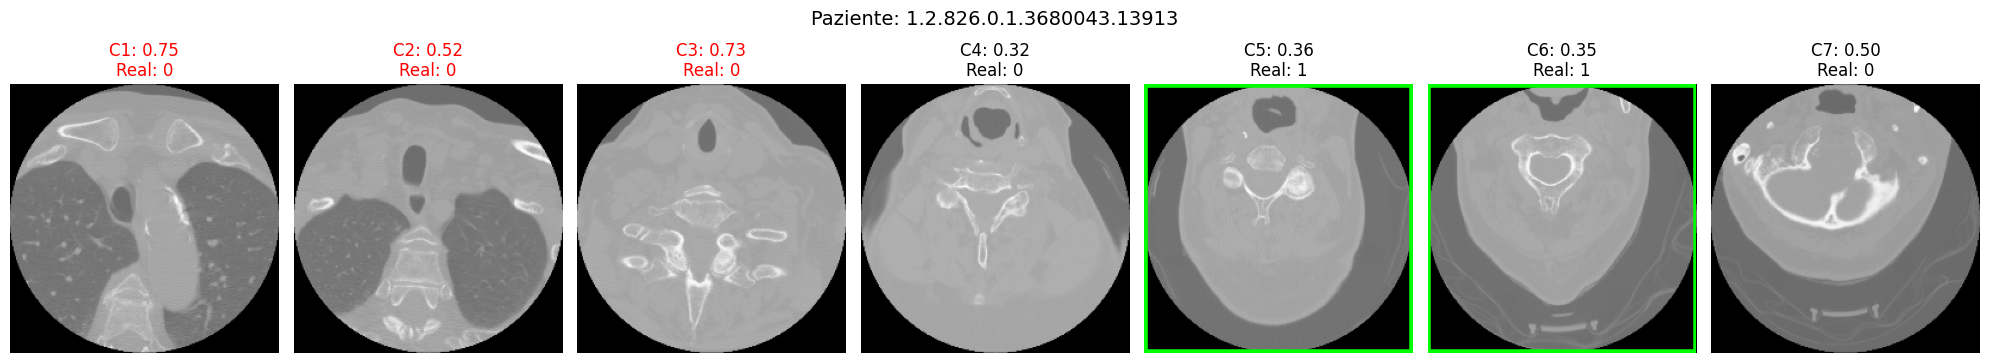

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2

def visualizza_predizioni(model, dataset, num_esempi=3):
    model.eval()
    device = next(model.parameters()).device

    for _ in range(num_esempi):
        idx = np.random.randint(0, len(dataset))
        inputs, labels = dataset[idx]
        uid = dataset.df.iloc[idx]['StudyInstanceUID']
        
        fig, axes = plt.subplots(1, 7, figsize=(20, 4))
        fig.suptitle(f"Paziente: {uid}", fontsize=14)

        for v_idx in range(7):
            # Prédiction
            with torch.no_grad():
                prob = torch.sigmoid(model(inputs.unsqueeze(0).to(device)))[0, v_idx].item()
            
        
            # je calcule dynamiquement le milieu pour éviter l'erreur "out of bounds"
            milieu = inputs.shape[1] // 2 
            img_base = inputs[v_idx, milieu].numpy() 
            
            # Affichage STRICTEMENT en gris (cmap='gray') pour bien voir les os
            axes[v_idx].imshow(img_base, cmap='gray')
            
            # Titre en rouge si le modèle suspecte une fracture (prob > 0.5)
            title_color = 'red' if prob > 0.5 else 'black'
            axes[v_idx].set_title(f"C{v_idx+1}: {prob:.2f}\nReal: {int(labels[v_idx])}", color=title_color)
            axes[v_idx].axis('off')
            
            # Cadre vert si c'est une VRAIE fracture
            if labels[v_idx] == 1:
                rect = plt.Rectangle((0,0), 223, 223, linewidth=4, edgecolor='lime', facecolor='none')
                axes[v_idx].add_patch(rect)
                
        plt.tight_layout()
        plt.show()

# Execution
model.to("cuda" if torch.cuda.is_available() else "cpu")
val_dataset_small = RSNAKaggleDataset(val_df.head(10), TRAIN_IMAGES_DIR, SEG_DIR)
visualizza_predizioni(model, val_dataset_small, num_esempi=3)